In [1]:
import torch
import matplotlib.pyplot as plt
from util import load_model, load_config, value_factor, plot_strategy
from model import VFNN
from util import load_dataset, load_dataset_no_split
import pandas as pd
import numpy as np
from classical_strategies import base_load, base_load_modified

In [2]:
model = load_model(model_path='/Users/zachl/Desktop/WindEnergyForecasting/test/77f28d1e-8d79-4dd1-823f-ed795bd50c08/hidden16_seqlen168_77f28d1e-8d79-4dd1-823f-ed795bd50c08.pth', 
                   config_path='./configs/config.yaml')

config = load_config('./configs/config.yaml')
dataset = load_dataset_no_split('../data/processed/dataset_2018-21_clean.csv', config)

/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold


Length of dataset: 34861


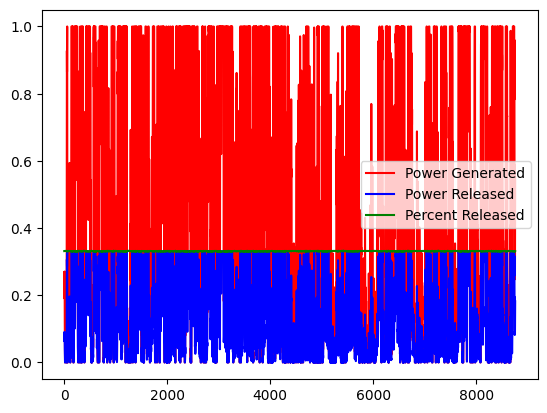

In [3]:
print(f'Length of dataset: {len(dataset)}')
idxs1mo = 24 * 30
idxs1yr = 24 * 365
dataset = dataset[:idxs1yr]

power = dataset[:,0].detach().cpu().numpy().squeeze()
price = dataset[:,1].detach().cpu().numpy().squeeze()

percent_release = model(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released = power * percent_release

x = np.arange(0, len(dataset))

plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, released, 'b', label='Power Released')
plt.plot(x, percent_release, '-g', label='Percent Released')
plt.legend()
plt.show()

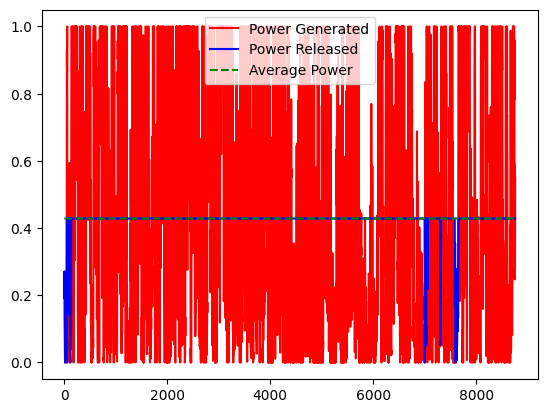

Raw VF: 0.6871009469032288
Base Load VF: 0.9934398181975804


In [4]:
base_load_released = base_load(power)

avg = np.repeat(np.mean(power), len(x))
plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, base_load_released, 'b', label='Power Released')
plt.plot(x, avg, '--g', label='Average Power')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
after_vf = value_factor(base_load_released, price)

print(f'Raw VF: {before_vf}')
print(f'Base Load VF: {after_vf}')

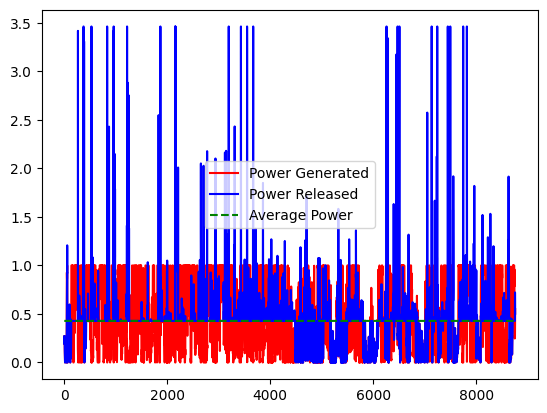

Raw VF: 0.6871009469032288
Base Load VF: 1.2965883154346616


In [ ]:
base_load_released = base_load_modified(power, price)

avg = np.repeat(np.mean(power), len(x))
plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, base_load_released, 'b', label='Power Released')
plt.plot(x, avg, '--g', label='Average Power')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
after_vf = value_factor(base_load_released, price)

print(f'Raw VF: {before_vf}')
print(f'Modified Base Load VF: {after_vf}')